In [1]:
import numpy as np
import matplotlib.pyplot as plt
from dadapy import MetricComparisons
from tqdm import tqdm

In [ ]:
data = np.load("/scratch/vdeltatt/imbalance-gain-causality/tests_for_debarshi/data/1_cn_tor.npy")
print(data.shape)

print((data < 0).any())
print((data[:,:,-3:] > 2*np.pi).any())
print(np.max(data[:,:,:5]))

: 

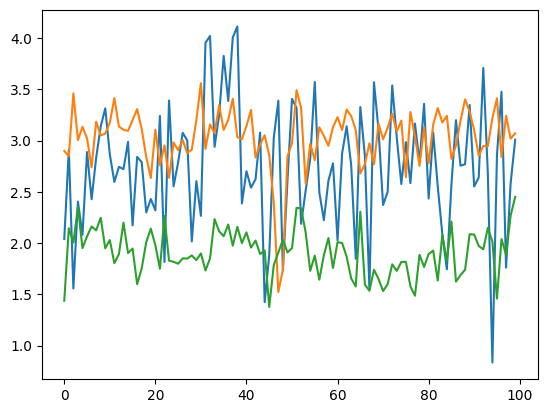

In [4]:
for i in range(3):
    plt.plot(data[0,:100,-i], '-')
plt.show()

### Test PBCs options in DADApy

In [25]:
X = data[:,0,-3:]

# no period
d = MetricComparisons(X, maxk=X.shape[0]-1)
ii = d.return_inf_imb_two_selected_coords(coords1=[0], coords2=[1])
print(ii)

# with correct period
d = MetricComparisons(X, maxk=X.shape[0]-1, period=2*np.pi)
ii = d.return_inf_imb_two_selected_coords(coords1=[0], coords2=[1])
print(ii)

# with giant period
d = MetricComparisons(X, maxk=X.shape[0]-1, period=1000*np.pi)
ii = d.return_inf_imb_two_selected_coords(coords1=[0], coords2=[1])
print(ii)

# with correct period only for first component, scaling second one
Xnew = +X
Xnew[:,1] /= 1000
d = MetricComparisons(Xnew, maxk=Xnew.shape[0]-1, period=2*np.pi)
ii = d.return_inf_imb_two_selected_coords(coords1=[0], coords2=[1])
print(ii)

# check that global scaling does not affect ii
Xnew = +X
Xnew[:,:] /= 1000
d = MetricComparisons(Xnew, maxk=Xnew.shape[0]-1)
ii = d.return_inf_imb_two_selected_coords(coords1=[0], coords2=[1])
print(ii)

# check that global scaling does not affect ii
Xnew = +X
Xnew[:,:] /= 1000
d = MetricComparisons(Xnew, maxk=Xnew.shape[0]-1, period=2*np.pi/1000)
ii = d.return_inf_imb_two_selected_coords(coords1=[0], coords2=[1])
print(ii)

(0.96028, 0.928462)
(0.9845280000000001, 0.9378099999999999)
(0.96028, 0.928462)


/home/vdeltatt/myjax_gpu/lib64/python3.8/site-packages/dadapy/_utils/utils.py:152: UserWarning: There are points with neighbours at 0 distance, meaning the dataset probably has identical points.
This can cause problems in various routines.
We suggest to either perform smearing of distances using
remove_zero_dists()
or remove identical points using
remove_identical_points()).
  warnings.warn(
/home/vdeltatt/myjax_gpu/lib64/python3.8/site-packages/dadapy/_utils/utils.py:152: UserWarning: There are points with neighbours at 0 distance, meaning the dataset probably has identical points.
This can cause problems in various routines.
We suggest to either perform smearing of distances using
remove_zero_dists()
or remove identical points using
remove_identical_points()).
  warnings.warn(


(0.96028, 0.936102)


/home/vdeltatt/myjax_gpu/lib64/python3.8/site-packages/dadapy/_utils/utils.py:152: UserWarning: There are points with neighbours at 0 distance, meaning the dataset probably has identical points.
This can cause problems in various routines.
We suggest to either perform smearing of distances using
remove_zero_dists()
or remove identical points using
remove_identical_points()).
  warnings.warn(


(0.96028, 0.928462)
(0.9845280000000001, 0.9378099999999999)


In [30]:
np.ravel([np.array([0,1])])

array([0, 1])

### Autocorrelation function

In [14]:
def autocorr2(x): # autocorrelation function
    r2=np.fft.ifft(np.abs(np.fft.fft(x))**2).real
    c=(r2/x.shape-np.mean(x)**2)/np.std(x)**2
    return c[:len(x)//2]

In [15]:
coords = np.arange(data.shape[2])

lag_max = 50
n_iid = 1000
acfs = np.zeros((len(coords), n_iid, lag_max))

for coord in tqdm(coords):
    for itraj in range(n_iid):
        acfs[coord, itraj] = autocorr2(data[0,5:,coord])[:lag_max]

100%|██████████| 8/8 [00:04<00:00,  1.80it/s]


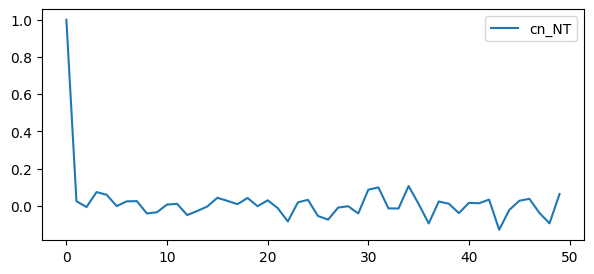

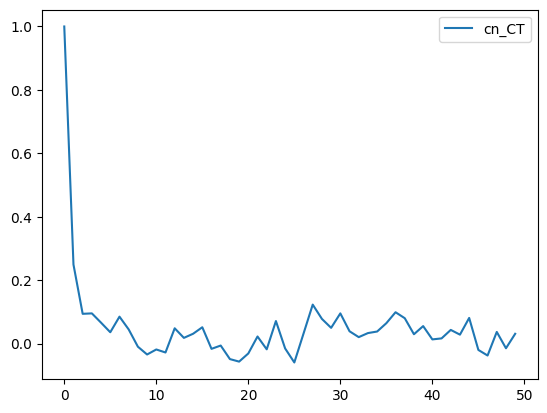

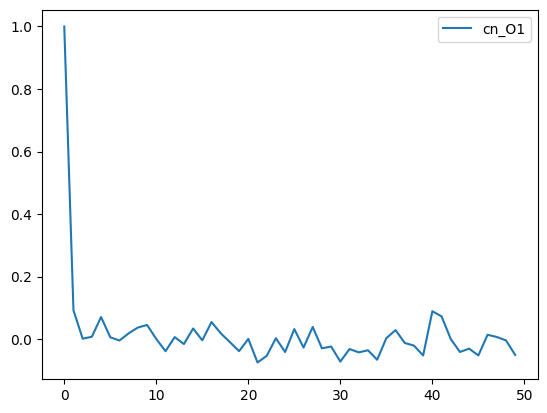

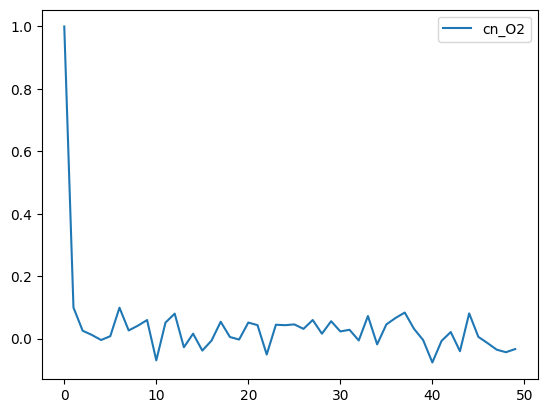

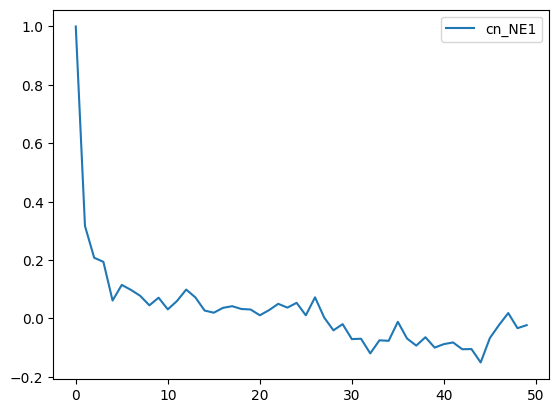

In [19]:
taus = np.arange(lag_max)
dict_cns = {0: "cn_NT", 1: "cn_CT", 2: "cn_O1", 3: "cn_O2", 4: "cn_NE1"}

plt.figure(figsize=(7,3))
for coord in coords[:5]:
    avg = acfs[coord].mean(axis=0)
    err = acfs[coord].std(axis=0) / np.sqrt(acfs[coord].shape[0])
    plt.plot(taus, avg, '-', label=dict_cns[coord])
    plt.fill_between(taus, avg - err, avg + err)
    plt.legend()
    plt.show()

### tor1 vs tor2, scatter plot

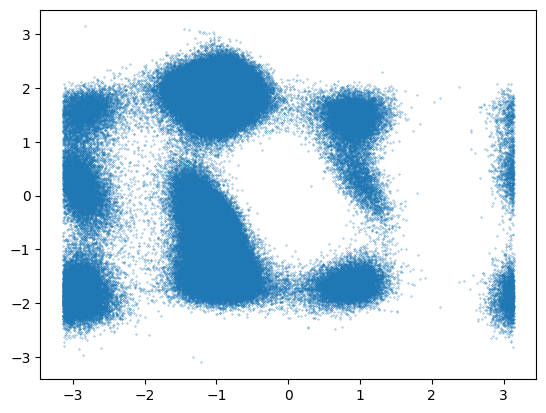

In [9]:
tor1 = np.ravel(data[:,:,-3])
tor1[tor1 > np.pi] = tor1[tor1 > np.pi] - 2*np.pi
tor2 = np.ravel(data[:,:,-2])
tor2[tor2 > np.pi] = tor2[tor2 > np.pi] - 2*np.pi
plt.plot(tor1, tor2, '.', markersize=0.5)

### tor1 vs tor3, scatter plot

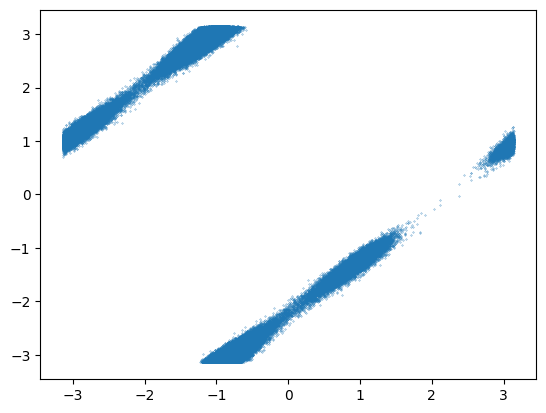

In [10]:
tor1 = np.ravel(data[:,:,-3])
tor1[tor1 > np.pi] = tor1[tor1 > np.pi] - 2*np.pi
tor3 = np.ravel(data[:,:,-1])
tor3[tor3 > np.pi] = tor3[tor3 > np.pi] - 2*np.pi
plt.plot(tor1, tor3, '.', markersize=0.5)

In [ ]:
tor1 = np.ravel(data[:,:,-3])
#tor1[tor1 > np.pi] = tor1[tor1 > np.pi] - 2*np.pi
cn = np.ravel(data[:,:,0])
plt.plot(tor1, cn, '.', markersize=0.5)

: 